# Cifar 10 Classification
## 1.4 Transfer Learning with ResNet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time 
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
import pandas as pd
import seaborn as sns

In [113]:
import random
import os

seed = 42
# Setting Python and NumPy seeds
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
    
# Setting PyTorch seeds (CPU and all GPUs)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
    
# Ensure deterministic behavior in cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [114]:
# Checking if CUDA is available and setting the device accordingly.
# If a GPU is available, it will be used for computations; otherwise, the code will fall back to the CPU.
# In this case, I am using an RTX 3060 GPU, which supports CUDA.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


In [115]:
TRAIN_MODEL = False
SAVE_MODEL = False

In [116]:
weights = ResNet18_Weights.DEFAULT
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
    ])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
    ])

batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=False, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=False, transform=test_transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [117]:
model = resnet18(weights=weights)

# Modifying the final fully connected layer of ResNet18 to output 10 classes instead of 1000
model.fc = nn.Linear(model.fc.in_features, 10)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Fine Tuning

In [118]:
# freeze all layers 
for param in model.parameters():
    param.requires_grad = False
# unfreeze fully connected layer
for param in model.fc.parameters():
    param.requires_grad = True
# unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

In [119]:
criterion = nn.CrossEntropyLoss()
# We will use different learning rates for the fully connected layer and the last convolutional block (layer4)
# since layer 4 pretrained weights has useful features that we want to preserve,
# while the fully connected layer is new and needs to learn from scratch.
optimizer = optim.Adam([{"params" : model.fc.parameters(), "lr" : 1e-3},
                        {"params" : model.layer4.parameters(), "lr" : 1e-4}])

In [120]:
if TRAIN_MODEL:
    # Train model
    train_loss=[]
    train_accuary=[]
    test_loss=[]
    test_accuary=[]

    num_epochs = 20   #(set number of epochs)
    start_time = time.time() #(for tracking time)
    # Start loop
    for epoch in range(num_epochs): #(loop for every epoch)
        print("Epoch {} running".format(epoch)) #(printing message)
        """ Training Phase """
        model.train()    #(training model)
        running_loss = 0.   #(set loss 0)
        running_corrects = 0 
        # load a batch data of images
        for i, (inputs, labels) in enumerate(trainloader):
            inputs = inputs.to(device)
            labels = labels.to(device) 
            # forward inputs and get output
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            # get loss value and update the network weights
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            running_corrects += torch.sum(preds == labels.data).item()
        epoch_loss = running_loss / len(trainset)
        epoch_acc = running_corrects / len(trainset) * 100.
        # Append result
        train_loss.append(epoch_loss)
        train_accuary.append(epoch_acc)
        # Print progress
        print('[Train #{}] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch+1, epoch_loss, epoch_acc, time.time() -start_time))
        """ Testing Phase """
        model.eval()
        with torch.no_grad():
            running_loss = 0.
            running_corrects = 0
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                running_corrects += torch.sum(preds == labels.data).item()
            epoch_loss = running_loss / len(testset)
            epoch_acc = running_corrects / len(testset) * 100.
            # Append result
            test_loss.append(epoch_loss)
            test_accuary.append(epoch_acc)
            # Print progress
            print('[Test #{}] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch+1, epoch_loss, epoch_acc, time.time()- start_time))

In [121]:
if SAVE_MODEL:
    PATH = "./models/cifar_pretrained_resnet_finetune.pth"
    torch.save(model, PATH)

In [122]:
# Saving the training and test loss and accuracy in tables for later analysis and visualization
if SAVE_MODEL:
    train_loss_table = pd.DataFrame(train_loss, columns=["Loss"])
    train_loss_table["Epoch"] = train_loss_table.index + 1

    train_accuracy_table = pd.DataFrame(train_accuary, columns=["Accuracy"])
    train_accuracy_table["Epoch"] = train_accuracy_table.index + 1
    
    test_loss_table = pd.DataFrame(test_loss, columns=["Loss"])
    test_loss_table["Epoch"] = test_loss_table.index + 1
    
    test_accuracy_table = pd.DataFrame(test_accuary, columns=["Accuracy"])
    test_accuracy_table["Epoch"] = test_accuracy_table.index + 1
    
    train_loss_table.to_csv("tables/ResNet_Pretrained/training_loss.csv", index=False)
    train_accuracy_table.to_csv("tables/ResNet_Pretrained/training_accuracy.csv", index=False)
    
    test_loss_table.to_csv("tables/ResNet_Pretrained/test_loss.csv", index=False)
    test_accuracy_table.to_csv("tables/ResNet_Pretrained/test_accuracy.csv", index=False)

In [123]:
# If SAVE_MODEL is False, we load our saved CSV files
if not SAVE_MODEL:
    train_loss_table = pd.read_csv("tables/ResNet_Pretrained/training_loss.csv")
    train_accuracy_table = pd.read_csv("tables/ResNet_Pretrained/training_accuracy.csv")
    test_loss_table = pd.read_csv("tables/ResNet_Pretrained/test_loss.csv")
    test_accuracy_table = pd.read_csv("tables/ResNet_Pretrained/test_accuracy.csv")
    
    print(train_loss_table.tail())
    print(train_accuracy_table.tail())
    print(test_loss_table.tail())
    print(test_accuracy_table.tail())
    


        Loss  Epoch
15  0.000648     16
16  0.000652     17
17  0.000633     18
18  0.000572     19
19  0.000492     20
    Accuracy  Epoch
15    98.576     16
16    98.596     17
17    98.626     18
18    98.738     19
19    98.914     20
        Loss  Epoch
15  0.004709     16
16  0.005026     17
17  0.004895     18
18  0.004775     19
19  0.005095     20
    Accuracy  Epoch
15     93.63     16
16     93.18     17
17     93.34     18
18     93.81     19
19     93.32     20


In [124]:
# Loading the saved model
if not TRAIN_MODEL:
    PATH = "./models/cifar_pretrained_resnet_finetune.pth"
    model = torch.load(PATH)
    model.to(device)

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_22032\1463152579.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(PATH)


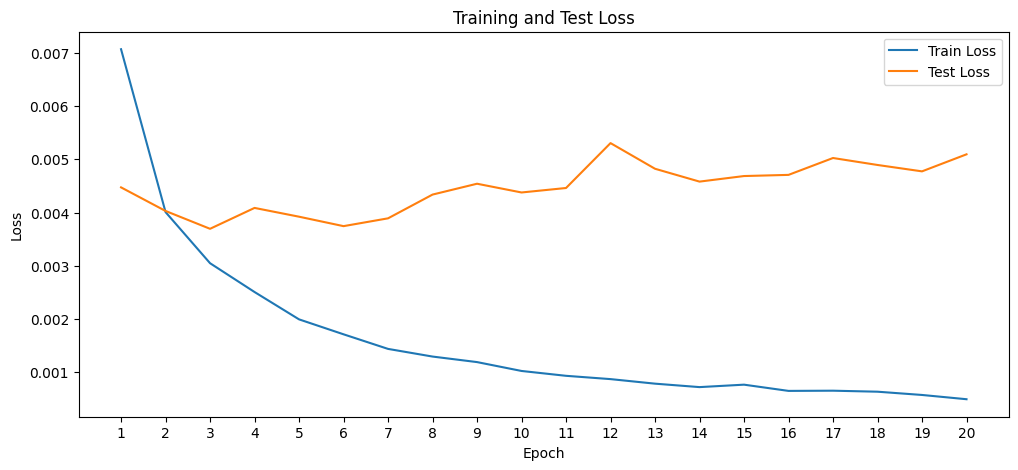

In [125]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=train_loss_table, x="Epoch", y="Loss", label="Train Loss")
sns.lineplot(data=test_loss_table, x="Epoch", y="Loss", label="Test Loss")
plt.title("Training and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(train_loss_table["Epoch"])
plt.legend()
plt.show()

## The training loss was steadily decreasing, however the test loss kept fluctuating and even increased at some epochs, which is a sign of overfitting.

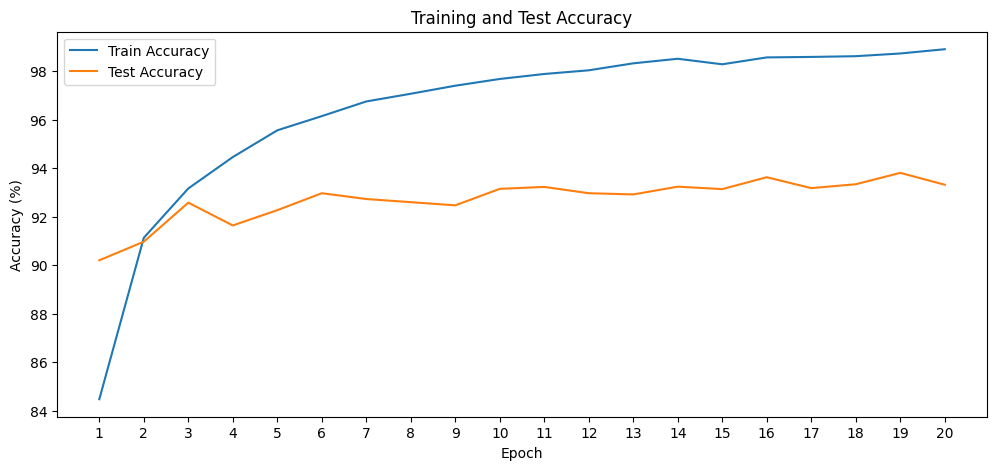

In [126]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=train_accuracy_table, x="Epoch", y="Accuracy", label="Train Accuracy")
sns.lineplot(data=test_accuracy_table, x="Epoch", y="Accuracy", label="Test Accuracy")
plt.title("Training and Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(train_accuracy_table["Epoch"])
plt.legend()
plt.show()

## The train accuracy was increasing and reached over 98%, while the test accuracy was fluctuating and stayed around 92%. this is a clear sign of overfitting, where the model performs well on the training data but struggles to generalize to unseen data.

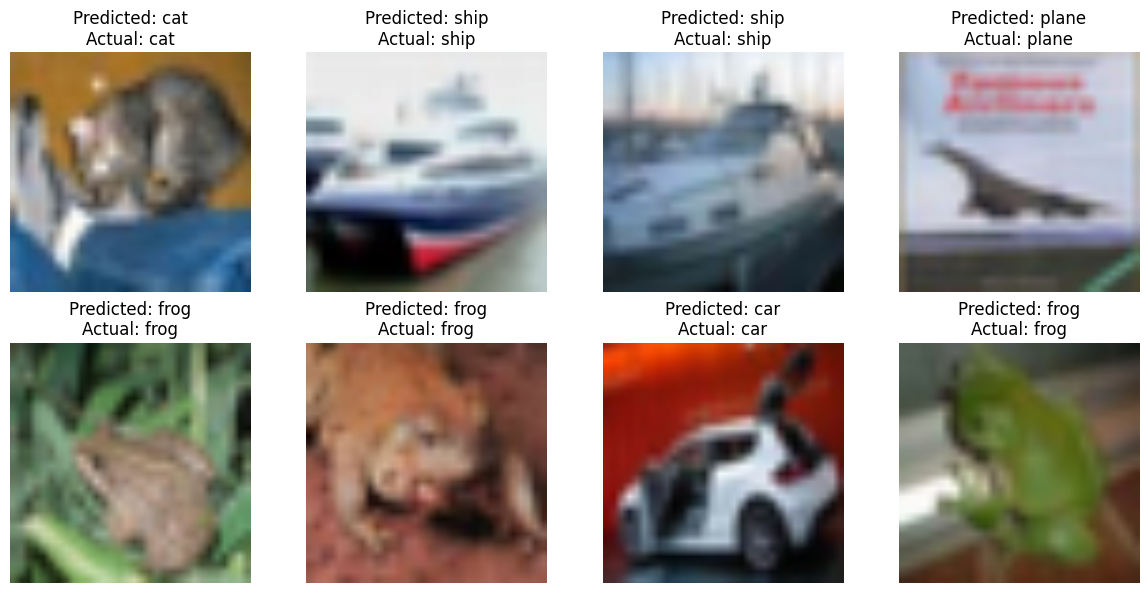

In [ ]:
# we will take a small sample of the test dataset
# and see how our model performs on it, then compare it to the actual labels
# also visualize the images with the predicted label above the actual label


# batch of test data
dataiter = iter(testloader)
images, labels = next(dataiter)

images = images[:8]
labels = labels[:8]

images = images.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    ax = axes[i // 4, i % 4]
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = (img * np.array(weights.transforms().std) + np.array(weights.transforms().mean)).clip(0, 1)
    ax.imshow(img)
    ax.set_title(f"Predicted: {classes[predicted[i].item()]}\nActual: {classes[labels[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Great Result it predicted each image correctly, and the predicted labels match the actual labels for all 8 images. This indicates that the model is performing well on this batch of test data.

Wrong predictions in this batch: 7


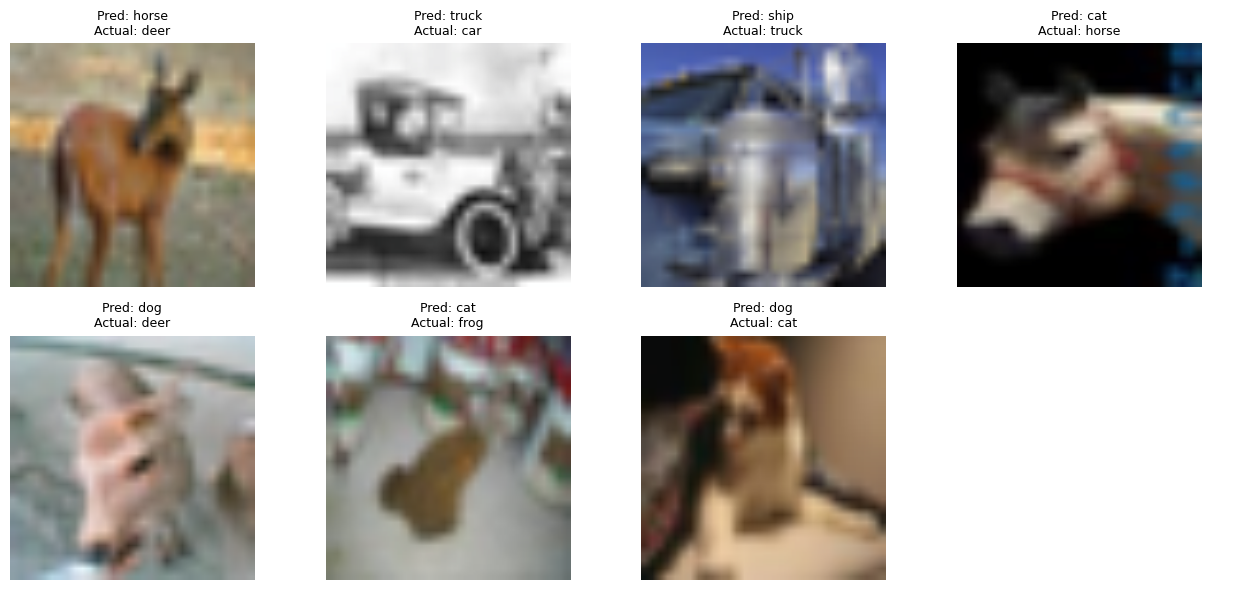

In [ ]:
# showing all wrong predictions from one test batch 
def show_wrong_images(model, testloader, classes, weights, device):
    model.eval()

    images, labels = next(iter(testloader))
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        predicted = outputs.argmax(dim=1)

    # taking the indices of wrong predictions
    wrong_indices = (predicted != labels).nonzero(as_tuple=True)[0]
    print(f"Wrong predictions in this batch: {len(wrong_indices)}")

    # Stopping early if no mistakes in this batch
    if len(wrong_indices) == 0:
        print("No wrong predictions in this batch. Run again for another batch.")
        return


    cols = 4
    rows = int(np.ceil(len(wrong_indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(rows, cols)

    # plottig each wrong image with predicted and actual labels
    for plot_idx, idx in enumerate(wrong_indices.tolist()):
        r, c = divmod(plot_idx, cols)
        ax = axes[r, c]

        img = images[idx].detach().cpu().numpy().transpose((1, 2, 0))
        img = (img * weights.transforms().std + weights.transforms().mean).clip(0, 1)

        pred_name = classes[predicted[idx].item()]
        true_name = classes[labels[idx].item()]

        ax.imshow(img)
        ax.set_title(f"Pred: {pred_name}\nActual: {true_name}", fontsize=9)
        ax.axis('off')

    # Hide empty subplot cells if grid is larger than number of wrong images
    for empty_idx in range(len(wrong_indices), rows * cols):
        r, c = divmod(empty_idx, cols)
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

show_wrong_images(model, testloader, classes, weights, device)

### Here the 7 images from the batch that were misclassified by the model are showed, the model got some obvious mistakes like predicting a dog as a cat, and a truck as a car it also got one less obvious mistake by predicting a deer as a horse even I thought it was a horse at first, this is only 7 wrong images in the whole batch which is 64 so this model overall is doing great 

In [134]:
# Loading from scratch model loss and accuracy tables for comparison
scratch_train_loss_table = pd.read_csv("tables/ResNet_Scratch/training_loss.csv")
scratch_train_accuracy_table = pd.read_csv("tables/ResNet_Scratch/training_accuracy.csv")
scratch_test_loss_table = pd.read_csv("tables/ResNet_Scratch/test_loss.csv")
scratch_test_accuracy_table = pd.read_csv("tables/ResNet_Scratch/test_accuracy.csv")

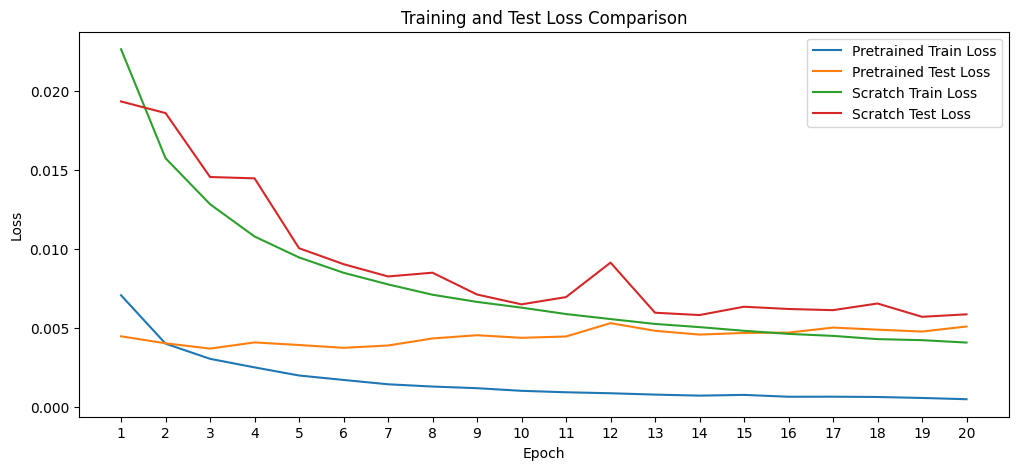

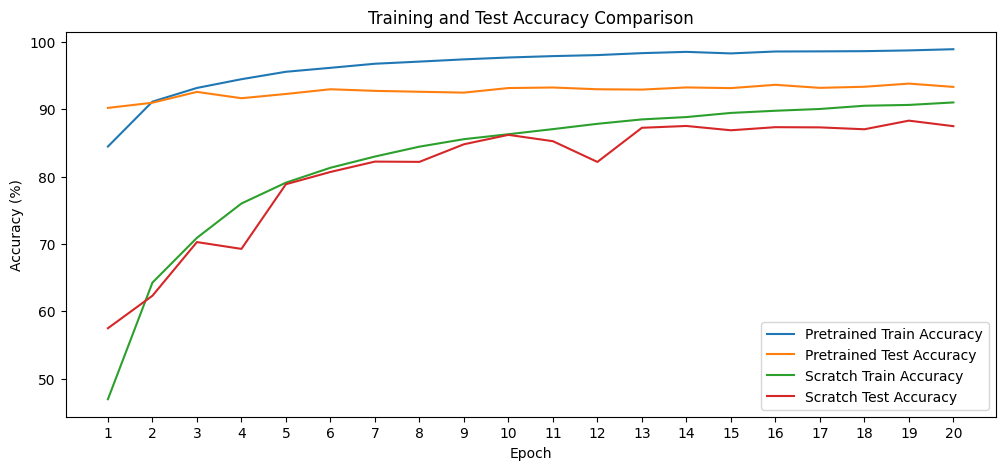

In [136]:
# Plotting Training and Testing Loss Curves for both models
plt.figure(figsize=(12, 5))
sns.lineplot(data=train_loss_table, x="Epoch", y="Loss", label="Pretrained Train Loss")
sns.lineplot(data=test_loss_table, x="Epoch", y="Loss", label="Pretrained Test Loss")
sns.lineplot(data=scratch_train_loss_table, x="Epoch", y="Loss", label="Scratch Train Loss")
sns.lineplot(data=scratch_test_loss_table, x="Epoch", y="Loss", label="Scratch Test Loss")
plt.title("Training and Test Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(train_loss_table["Epoch"])
plt.legend()
plt.show()

# Plotting Training and Testing Accuracy Curves for both models
plt.figure(figsize=(12, 5))
sns.lineplot(data=train_accuracy_table, x="Epoch", y="Accuracy", label="Pretrained Train Accuracy")
sns.lineplot(data=test_accuracy_table, x="Epoch", y="Accuracy", label="Pretrained Test Accuracy")
sns.lineplot(data=scratch_train_accuracy_table, x="Epoch", y="Accuracy", label="Scratch Train Accuracy")
sns.lineplot(data=scratch_test_accuracy_table, x="Epoch", y="Accuracy", label="Scratch Test Accuracy")
plt.title("Training and Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(train_accuracy_table["Epoch"])
plt.legend()
plt.show()

## it's clear that the pretrained ResNet18 model with transfer learning has significantly outperformed the model trained from scratch, achieving higher accuracy and lower loss on both training and test sets. This shows how much better transfer learning can be compared to training from scratch, especially when the dataset is close to the original dataset the model was trained on which is imagenet, yes the model overfit a little bit but it still has a very good performance on the test set which is the most important thing.